In [3]:
# step 1 # load and explore the dataset
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import networkx as nx
import seaborn as sns

In [4]:

file_path = "../data/train.txt"

triples = []

with open(file_path, "r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if line:  # skip empty lines
            head, relation, tail = line.split()
            triples.append((head, relation, tail))
print(f"Total triples loaded: {len(triples)}")

Total triples loaded: 13821


In [5]:
df = pd.DataFrame(triples, columns=["head", "relation", "tail"])
df.head()

,head,relation,tail
0,olivia0,sisterOf,selina10
1,olivia0,sisterOf,isabella11
2,olivia0,sisterOf,oskar24
3,olivia0,sisterOf,adam9
4,olivia0,secondAuntOf,lena18


In [6]:
entities = pd.unique(df[["head", "tail"]].values.ravel())

len(entities)


1316

In [7]:

relations = pd.unique(df["relation"].values.ravel())
len(relations)

28

In [8]:
unique_nodes = pd.unique(df[["head", "tail"]].values.ravel())
unique_nodes = unique_nodes.tolist()
len(unique_nodes), unique_nodes[:10]
# print(f"Total unique entities: {len(unique_nodes)}")

(1316,
 ['olivia0',
  'selina10',
  'isabella11',
  'oskar24',
  'adam9',
  'lena18',
  'fabian26',
  'leon16',
  'johanna22',
  'jonas23'])

In [9]:
# Count occurrences of each relation
relation_counts = df["relation"].value_counts()

# Convert to dictionary
relation_count_dict = relation_counts.to_dict()

# Inspect
relation_count_dict


{'grandsonOf': 814,
 'grandmotherOf': 813,
 'grandfatherOf': 813,
 'granddaughterOf': 812,
 'motherOf': 733,
 'fatherOf': 733,
 'sisterOf': 636,
 'daughterOf': 628,
 'greatGrandsonOf': 624,
 'greatGrandmotherOf': 617,
 'greatGrandfatherOf': 617,
 'greatGranddaughterOf': 610,
 'sonOf': 600,
 'brotherOf': 570,
 'auntOf': 556,
 'nephewOf': 514,
 'nieceOf': 496,
 'uncleOf': 454,
 'girlCousinOf': 445,
 'boyCousinOf': 391,
 'greatAuntOf': 312,
 'greatUncleOf': 237,
 'boyFirstCousinOnceRemovedOf': 180,
 'secondAuntOf': 175,
 'secondUncleOf': 158,
 'girlFirstCousinOnceRemovedOf': 153,
 'boySecondCousinOf': 68,
 'girlSecondCousinOf': 62}

In [10]:
relation_stats_df = relation_counts.reset_index()
relation_stats_df.columns = ["relation", "count"]

relation_stats_df


,relation,count
0,grandsonOf,814
1,grandmotherOf,813
2,grandfatherOf,813
3,granddaughterOf,812
4,motherOf,733
5,fatherOf,733
6,sisterOf,636
7,daughterOf,628
8,greatGrandsonOf,624
9,greatGrandmotherOf,617


In [11]:
print("Total triples:", len(df))
print("Unique number of people in the knowledge graph:", len(unique_nodes))
print("Unique relations:", len(relation_count_dict))



Total triples: 13821
Unique number of people in the knowledge graph: 1316
Unique relations: 28


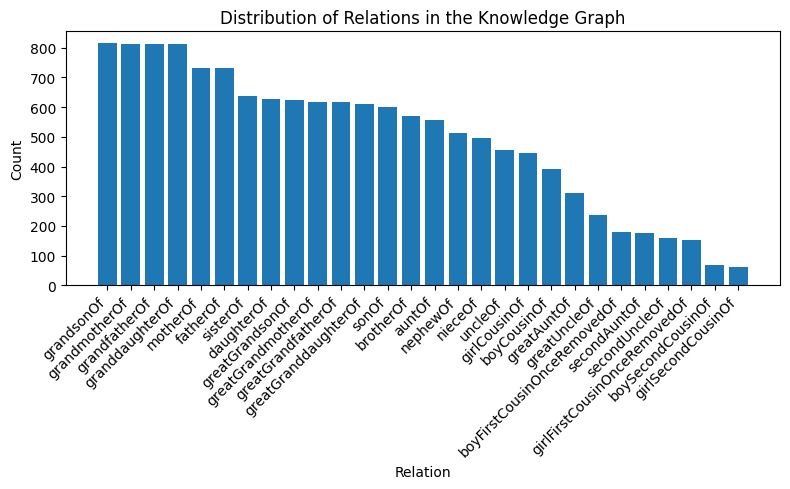

In [12]:
plt.figure(figsize=(8, 5))

plt.bar(
    relation_stats_df["relation"],
    relation_stats_df["count"]
)

plt.xlabel("Relation")
plt.ylabel("Count")
plt.title("Distribution of Relations in the Knowledge Graph")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.show()


In [13]:
G = nx.MultiDiGraph()
for _, row in df.iterrows():
    G.add_edge(
        row["head"],
        row["tail"],
        relation=row["relation"]
    )
print(f"Graph has {G.number_of_nodes()} nodes and {G.number_of_edges()} edges.")


Graph has 1316 nodes and 13821 edges.


In [14]:
list(G.edges(data=True))[:5]


[('olivia0', 'selina10', {'relation': 'sisterOf'}),
 ('olivia0', 'isabella11', {'relation': 'sisterOf'}),
 ('olivia0', 'oskar24', {'relation': 'sisterOf'}),
 ('olivia0', 'adam9', {'relation': 'sisterOf'}),
 ('olivia0', 'lena18', {'relation': 'secondAuntOf'})]

In [15]:
# Relavant statistics about the knowledge graph
print("Total triples:", len(df))
print("Unique number of people in the knowledge graph:", len(unique_nodes))
print("Unique relations:", len(relation_count_dict))
# Additional statistics
print("Number of nodes in the graph:", G.number_of_nodes())
print("Number of edges in the graph:", G.number_of_edges())

Total triples: 13821
Unique number of people in the knowledge graph: 1316
Unique relations: 28
Number of nodes in the graph: 1316
Number of edges in the graph: 13821


In [16]:
# Degree distribution
# List of tuples: (node_id, indegree, outdegree)
degree_tuples = [
    (node, G.in_degree(node), G.out_degree(node))
    for node in G.nodes()
]

# Inspect first few
degree_tuples[:10]


[('olivia0', 19, 20),
 ('selina10', 21, 21),
 ('isabella11', 21, 21),
 ('oskar24', 21, 21),
 ('adam9', 21, 21),
 ('lena18', 20, 17),
 ('fabian26', 20, 17),
 ('leon16', 19, 19),
 ('johanna22', 19, 19),
 ('jonas23', 17, 19)]

In [17]:
import pandas as pd

degree_df = pd.DataFrame(
    degree_tuples,
    columns=["node_id", "in_degree", "out_degree"]
)

degree_df.head()


,node_id,in_degree,out_degree
0,olivia0,19,20
1,selina10,21,21
2,isabella11,21,21
3,oskar24,21,21
4,adam9,21,21


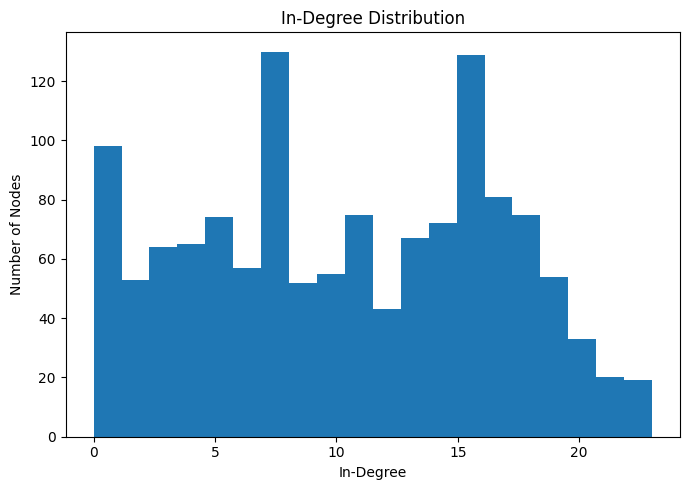

In [18]:
plt.figure(figsize=(7, 5))

plt.hist(degree_df["in_degree"], bins=20)

plt.xlabel("In-Degree")
plt.ylabel("Number of Nodes")
plt.title("In-Degree Distribution")

plt.tight_layout()
plt.show()


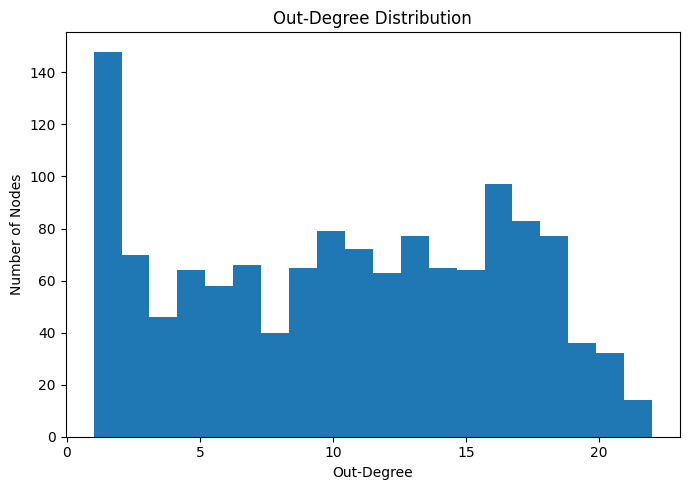

In [19]:
plt.figure(figsize=(7, 5))

plt.hist(degree_df["out_degree"], bins=20)

plt.xlabel("Out-Degree")
plt.ylabel("Number of Nodes")
plt.title("Out-Degree Distribution")

plt.tight_layout()
plt.show()


In [20]:
in_degree_mean = degree_df["in_degree"].mean()
in_degree_median = degree_df["in_degree"].median()
in_degree_mode = degree_df["in_degree"].mode().tolist()  # can be multiple
in_degree_max = degree_df["in_degree"].max()

print("In-Degree Statistics")
print("Mean:", in_degree_mean)
print("Median:", in_degree_median)
print("Mode(s):", in_degree_mode)
print("Max:", in_degree_max)


In-Degree Statistics
Mean: 10.50227963525836
Median: 11.0
Mode(s): [1]
Max: 23


In [21]:
out_degree_mean = degree_df["out_degree"].mean()
out_degree_median = degree_df["out_degree"].median()
out_degree_mode = degree_df["out_degree"].mode().tolist()  # can be multiple
out_degree_max = degree_df["out_degree"].max()

print("Out-Degree Statistics")
print("Mean:", out_degree_mean)
print("Median:", out_degree_median)
print("Mode(s):", out_degree_mode)
print("Max:", out_degree_max)

Out-Degree Statistics
Mean: 10.50227963525836
Median: 11.0
Mode(s): [16]
Max: 22


In [22]:
k = 5  # we can change k as needed

topk_in_degree = degree_df.sort_values(
    by="in_degree", ascending=False
).head(k)

topk_in_degree


,node_id,in_degree,out_degree
1032,dominik1036,23,22
1036,oliver1045,23,22
1040,lisa1035,23,22
1035,magdalena1044,23,22
644,valentin638,22,20


In [23]:
l = 5  # we can change l as needed
topk_out_degree = degree_df.sort_values(
    by="out_degree", ascending=False
).head(l)

topk_out_degree


,node_id,in_degree,out_degree
139,fabian140,22,22
138,larissa136,22,22
137,oskar133,22,22
154,laura143,20,22
1032,dominik1036,23,22


In [24]:
# Convert to undirected graph and calculate total degrees
G_undirected = nx.Graph(G)
total_degrees = dict(G_undirected.degree())

total_degree_df = pd.DataFrame(
    list(total_degrees.items()),
     columns=["node", "total_degree"]
     )
total_degree_df.sort_values(by="total_degree", ascending=False, inplace=True)
total_degree_df.head()

,node,total_degree
1035,magdalena1044,23
1036,oliver1045,23
1040,lisa1035,23
1034,olivia1043,23
1032,dominik1036,23


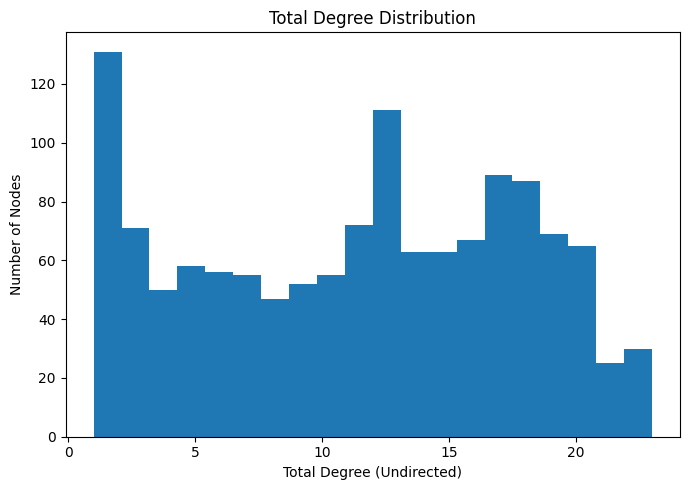

In [25]:
plt.figure(figsize=(7, 5))

plt.hist(total_degree_df["total_degree"], bins=20)

plt.xlabel("Total Degree (Undirected)")
plt.ylabel("Number of Nodes")
plt.title("Total Degree Distribution")

plt.tight_layout()
plt.show()

In [26]:
# Statistics for total degree (undirected)
total_degree_stats = {
    "mean": total_degree_df["total_degree"].mean(),
    "median": total_degree_df["total_degree"].median(),
    "max": total_degree_df["total_degree"].max(),
    "min": total_degree_df["total_degree"].min(),
}
print("Total Degree Stats (Undirected):")
print(total_degree_stats)

# Top k nodes by total degree
k = 5
topk_total_degree = total_degree_df.head(k)
print(f"\nTop {k} nodes by total degree:")
topk_total_degree

Total Degree Stats (Undirected):
{'mean': np.float64(11.367781155015198), 'median': np.float64(12.0), 'max': np.int64(23), 'min': np.int64(1)}

Top 5 nodes by total degree:


,node,total_degree
1035,magdalena1044,23
1036,oliver1045,23
1040,lisa1035,23
1034,olivia1043,23
1032,dominik1036,23


In [27]:
# Doing stats on each family by calculating connected components

# Get weakly connected components (each ≈ one family)
components = list(nx.weakly_connected_components(G))

# Number of families
num_families = len(components)
num_families


50

In [28]:
# Dictionary: {family_id: family_size}
family_size_dict = {
    idx: len(component)
    for idx, component in enumerate(components)
}

family_size_dict


{0: 27,
 1: 26,
 2: 26,
 3: 26,
 4: 26,
 5: 27,
 6: 26,
 7: 27,
 8: 26,
 9: 26,
 10: 26,
 11: 26,
 12: 26,
 13: 27,
 14: 26,
 15: 26,
 16: 26,
 17: 26,
 18: 27,
 19: 26,
 20: 27,
 21: 26,
 22: 26,
 23: 26,
 24: 26,
 25: 26,
 26: 26,
 27: 27,
 28: 26,
 29: 26,
 30: 27,
 31: 27,
 32: 27,
 33: 26,
 34: 27,
 35: 26,
 36: 26,
 37: 27,
 38: 26,
 39: 27,
 40: 26,
 41: 26,
 42: 26,
 43: 27,
 44: 26,
 45: 27,
 46: 26,
 47: 27,
 48: 26,
 49: 26}

In [29]:
family_size_df = pd.DataFrame(
    list(family_size_dict.items()),
    columns=["family_id", "family_size"]
)

family_size_df.head()

,family_id,family_size
0,0,27
1,1,26
2,2,26
3,3,26
4,4,26


In [30]:
family_size_stats = {
    "mean": family_size_df["family_size"].mean(),
    "median": family_size_df["family_size"].median(),
    "mode": family_size_df["family_size"].mode().tolist(),  # can be multiple
    "max": family_size_df["family_size"].max(),
    "min": family_size_df["family_size"].min()
}

family_size_stats


{'mean': np.float64(26.32),
 'median': np.float64(26.0),
 'mode': [26],
 'max': np.int64(27),
 'min': np.int64(26)}

In [31]:
summary_family_size_df = pd.DataFrame(
    list(family_size_stats.items()),
    columns=["statistic", "value"]
)

summary_family_size_df


,statistic,value
0,mean,26.32
1,median,26.0
2,mode,[26]
3,max,27
4,min,26


In [32]:
# Families with maximum size
families_max_size = family_size_df[
    family_size_df["family_size"] == family_size_stats["max"]
]

# Families with minimum size
families_min_size = family_size_df[
    family_size_df["family_size"] == family_size_stats["min"]
]

families_max_size, families_min_size


(    family_id  family_size
 0           0           27
 5           5           27
 7           7           27
 13         13           27
 18         18           27
 20         20           27
 27         27           27
 30         30           27
 31         31           27
 32         32           27
 34         34           27
 37         37           27
 39         39           27
 43         43           27
 45         45           27
 47         47           27,
     family_id  family_size
 1           1           26
 2           2           26
 3           3           26
 4           4           26
 6           6           26
 8           8           26
 9           9           26
 10         10           26
 11         11           26
 12         12           26
 14         14           26
 15         15           26
 16         16           26
 17         17           26
 19         19           26
 21         21           26
 22         22           26
 23         23     

In [33]:
# Population variance (treating your dataset as the full population)
family_size_variance = family_size_df["family_size"].var(ddof=0)

family_size_variance


np.float64(0.2176)

In [34]:
# Sample variance (default in pandas)
family_size_sample_variance = family_size_df["family_size"].var() # ddof = 1 default in pandas for sample variance
 
family_size_sample_variance


np.float64(0.22204081632653058)

In [35]:
family_size_std = family_size_df["family_size"].std(ddof=0)

family_size_std



np.float64(0.466476151587624)

In [36]:
# Sample standard deviation (default in pandas)
family_size_sample_std = family_size_df["family_size"].std() # ddof = 1 default in pandas for sample std
family_size_sample_std

np.float64(0.47121207149916117)

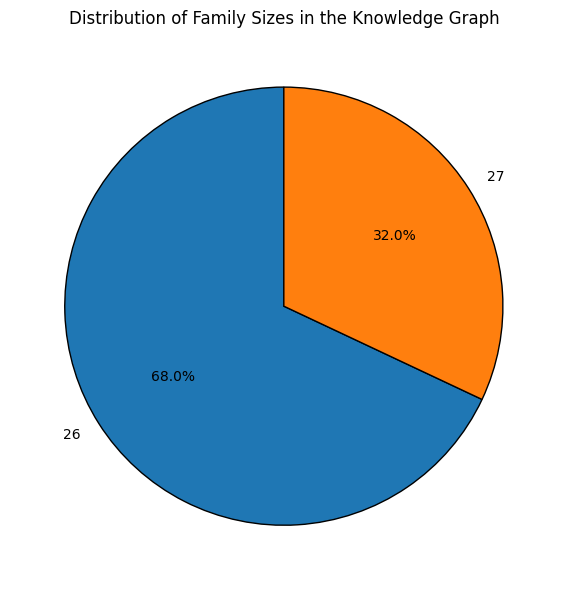

In [37]:
# plt.figure(figsize=(7, 5))

# plt.hist(
#     family_size_df["family_size"],
#     bins=20
# )

# plt.xlabel("Family Size (Connected Component Size)")
# plt.ylabel("Number of Families")
# plt.title("Distribution of Family Sizes in the Knowledge Graph")

# plt.tight_layout()
# plt.show()

family_size_counts = family_size_df["family_size"].value_counts()

plt.figure(figsize=(6, 6))

plt.pie(
    family_size_counts.values,
    labels=family_size_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"edgecolor": "black", "linewidth": 1}
)

plt.title("Distribution of Family Sizes in the Knowledge Graph", fontsize=12)
plt.tight_layout()
plt.show()



In [38]:
family_size_df.sort_values(by="family_size", ascending=False).head(10)

,family_id,family_size
0,0,27
5,5,27
13,13,27
7,7,27
31,31,27
30,30,27
45,45,27
47,47,27
39,39,27
43,43,27


In [39]:
# centrality measures
degree_centrality_records = []
betweenness_centrality_records = []

for family_id, nodes in enumerate(components):
    # Extract subgraph for this family
    subgraph = G.subgraph(nodes)
    
    # Convert to undirected simple graph
    undirected_subgraph = nx.Graph(subgraph)
    
    # Compute centralities
    deg_cent = nx.degree_centrality(undirected_subgraph)
    bet_cent = nx.betweenness_centrality(undirected_subgraph)
    
    # Store degree centrality
    for node, value in deg_cent.items():
        degree_centrality_records.append(
            (family_id, node, value)
        )
    
    # Store betweenness centrality
    for node, value in bet_cent.items():
        betweenness_centrality_records.append(
            (family_id, node, value)
        )


In [40]:
degree_centrality_df = pd.DataFrame(
    degree_centrality_records,
    columns=["family_id", "node_id", "degree_centrality"]
)

degree_centrality_df.head()


,family_id,node_id,degree_centrality
0,0,lisa5,0.846154
1,0,nico4,0.846154
2,0,natalie13,0.692308
3,0,paula12,0.692308
4,0,ella19,0.346154


In [41]:
betweenness_centrality_df = pd.DataFrame(
    betweenness_centrality_records,
    columns=["family_id", "node_id", "betweenness_centrality"]
)

betweenness_centrality_df.head()


,family_id,node_id,betweenness_centrality
0,0,lisa5,0.041420
1,0,nico4,0.041420
2,0,natalie13,0.000181
3,0,paula12,0.000181
4,0,ella19,0.000000


In [42]:
centrality_df = pd.merge(
    degree_centrality_df,
    betweenness_centrality_df,
    on=["family_id", "node_id"],
    how="inner"
)

centrality_df.head()


,family_id,node_id,degree_centrality,betweenness_centrality
0,0,lisa5,0.846154,0.041420
1,0,nico4,0.846154,0.041420
2,0,natalie13,0.692308,0.000181
3,0,paula12,0.692308,0.000181
4,0,ella19,0.346154,0.000000


In [43]:
deg_family_stats = centrality_df.groupby("family_id")["degree_centrality"].agg(
    mean="mean",
    median="median",
    max="max",
    min="min"
).reset_index()

deg_family_stats.head()


,family_id,mean,median,max,min
0,0,0.586895,0.692308,0.846154,0.038462
1,1,0.329231,0.300000,0.800000,0.040000
2,2,0.458462,0.440000,0.880000,0.040000
3,3,0.464615,0.560000,0.760000,0.040000
4,4,0.498462,0.520000,0.800000,0.040000


In [44]:
bet_family_stats = centrality_df.groupby("family_id")["betweenness_centrality"].agg(
    mean="mean",
    median="median",
    max="max",
    min="min"
).reset_index()

bet_family_stats.head()


,family_id,mean,median,max,min
0,0,0.018803,0.000342,0.112489,0.0
1,1,0.034872,0.006296,0.275657,0.0
2,2,0.026795,0.002182,0.114269,0.0
3,3,0.030256,0.018828,0.101844,0.0
4,4,0.025897,0.006577,0.086577,0.0


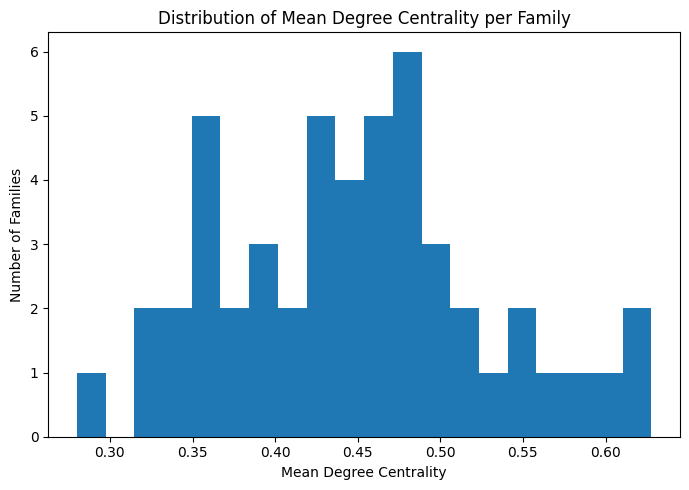

In [45]:
plt.figure(figsize=(7, 5))
plt.hist(deg_family_stats["mean"], bins=20)
plt.xlabel("Mean Degree Centrality")
plt.ylabel("Number of Families")
plt.title("Distribution of Mean Degree Centrality per Family")
plt.tight_layout()
plt.show()


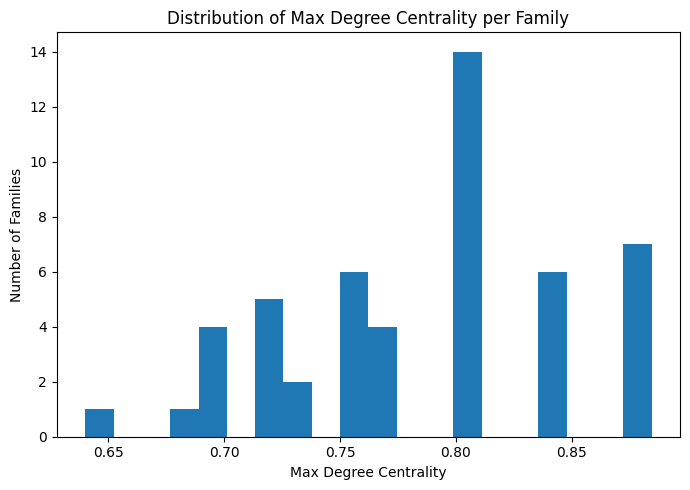

In [46]:
plt.figure(figsize=(7, 5))
plt.hist(deg_family_stats["max"], bins=20)
plt.xlabel("Max Degree Centrality")
plt.ylabel("Number of Families")
plt.title("Distribution of Max Degree Centrality per Family")
plt.tight_layout()
plt.show()


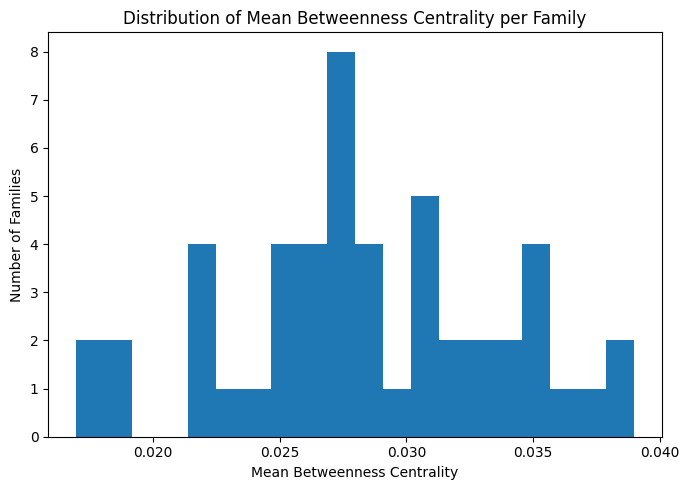

In [47]:
plt.figure(figsize=(7, 5))
plt.hist(bet_family_stats["mean"], bins=20)
plt.xlabel("Mean Betweenness Centrality")
plt.ylabel("Number of Families")
plt.title("Distribution of Mean Betweenness Centrality per Family")
plt.tight_layout()
plt.show()


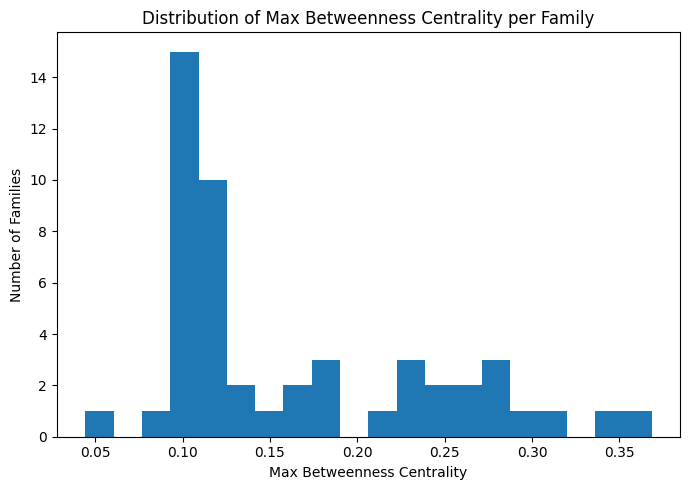

In [48]:
plt.figure(figsize=(7, 5))
plt.hist(bet_family_stats["max"], bins=20)
plt.xlabel("Max Betweenness Centrality")
plt.ylabel("Number of Families")
plt.title("Distribution of Max Betweenness Centrality per Family")
plt.tight_layout()
plt.show()


In [49]:
family_centrality_stats = {
    "degree_centrality": deg_family_stats,
    "betweenness_centrality": bet_family_stats
}


In [50]:
# Count occurrences of each relation
relation_counts = df["relation"].value_counts()

# Convert counts to probabilities
relation_probs = relation_counts / relation_counts.sum()

# Compute Shannon entropy
global_relation_entropy = -np.sum(
    relation_probs * np.log(relation_probs)
)

global_relation_entropy


np.float64(3.1964543353144315)

In [51]:
relation_prob_df = pd.DataFrame({
    "relation": relation_probs.index,
    "probability": relation_probs.values
})

relation_prob_df


,relation,probability
0,grandsonOf,0.058896
1,grandmotherOf,0.058824
2,grandfatherOf,0.058824
3,granddaughterOf,0.058751
4,motherOf,0.053035
5,fatherOf,0.053035
6,sisterOf,0.046017
7,daughterOf,0.045438
8,greatGrandsonOf,0.045149
9,greatGrandmotherOf,0.044642


In [52]:
global_relation_dominance = relation_probs.max()
global_relation_dominance


np.float64(0.05889588307647782)

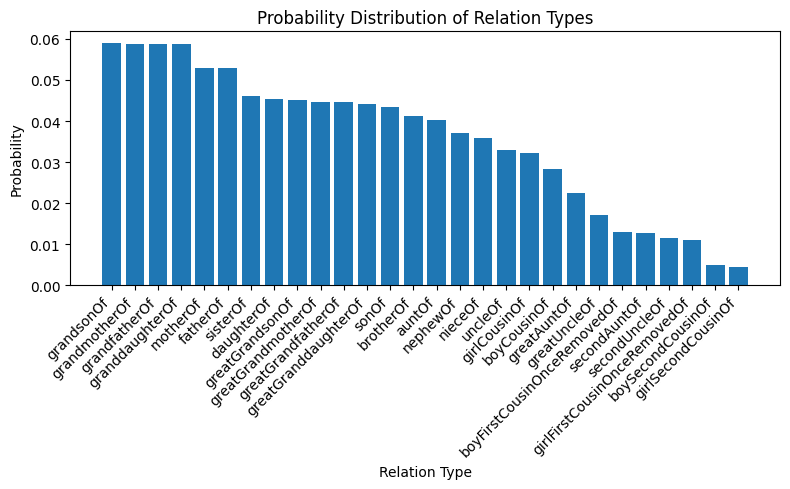

In [53]:

plt.figure(figsize=(8, 5))

plt.bar(
    relation_probs.index,
    relation_probs.values
)

plt.xlabel("Relation Type")
plt.ylabel("Probability")
plt.title("Probability Distribution of Relation Types")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


In [54]:
# Family wise entropy of the knowledge graph
node_to_family = {}

for family_id, nodes in enumerate(components):
    for node in nodes:
        node_to_family[node] = family_id


In [55]:
df["family_id"] = df["head"].map(node_to_family)

df.head()
# len(df)

,head,relation,tail,family_id
0,olivia0,sisterOf,selina10,0
1,olivia0,sisterOf,isabella11,0
2,olivia0,sisterOf,oskar24,0
3,olivia0,sisterOf,adam9,0
4,olivia0,secondAuntOf,lena18,0


In [56]:
family_entropy_records = []

for family_id, group in df.groupby("family_id"):
    # Count relations in this family
    relation_counts = group["relation"].value_counts()
    
    # Convert to probabilities
    relation_probs = relation_counts / relation_counts.sum()
    
    # Shannon entropy
    entropy = -np.sum(relation_probs * np.log(relation_probs))
    
    family_entropy_records.append(
        (family_id, entropy)
    )


In [57]:
family_entropy_df = pd.DataFrame(
    family_entropy_records,
    columns=["family_id", "relation_entropy"]
)

family_entropy_df.head()


,family_id,relation_entropy
0,0,3.256092
1,1,2.884054
2,2,3.059298
3,3,3.251684
4,4,3.223268


In [58]:
family_entropy_df = family_entropy_df.merge(
    family_size_df,
    on="family_id",
    how="left"
)

family_entropy_df.head()


,family_id,relation_entropy,family_size
0,0,3.256092,27
1,1,2.884054,26
2,2,3.059298,26
3,3,3.251684,26
4,4,3.223268,26


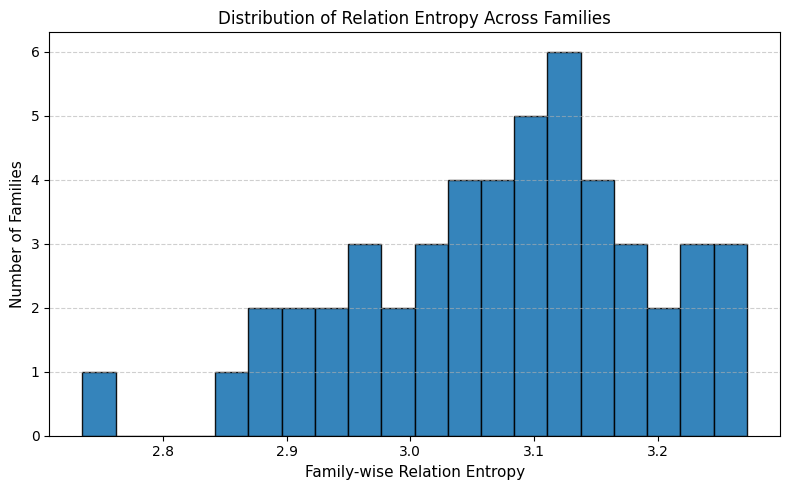

In [59]:
plt.figure(figsize=(8, 5))

plt.hist(
    family_entropy_df["relation_entropy"],
    bins=20,
    edgecolor="black",
    linewidth=1,
    alpha=0.9
)

plt.xlabel("Family-wise Relation Entropy", fontsize=11)
plt.ylabel("Number of Families", fontsize=11)
plt.title("Distribution of Relation Entropy Across Families", fontsize=12)

plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()



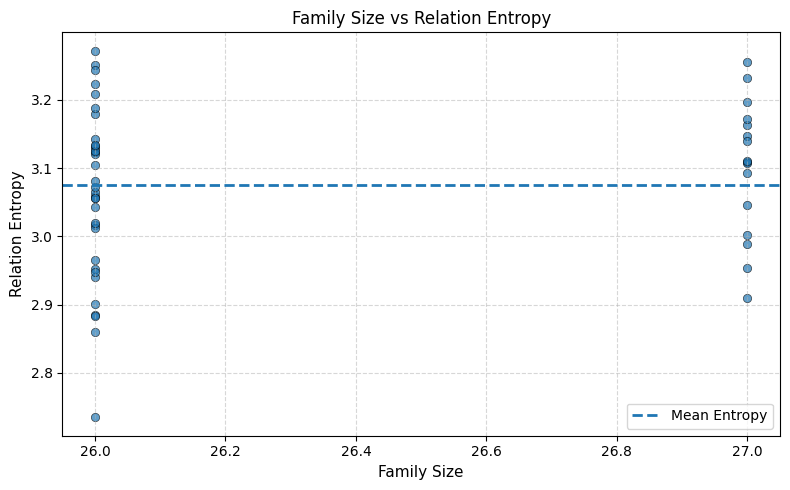

In [60]:
plt.figure(figsize=(8, 5))

plt.scatter(
    family_entropy_df["family_size"],
    family_entropy_df["relation_entropy"],
    alpha=0.7,
    edgecolors="black",
    linewidths=0.5
)

# Mean entropy line
mean_entropy = family_entropy_df["relation_entropy"].mean()
plt.axhline(
    mean_entropy,
    linestyle="--",
    linewidth=2,
    label="Mean Entropy"
)

plt.xlabel("Family Size", fontsize=11)
plt.ylabel("Relation Entropy", fontsize=11)
plt.title("Family Size vs Relation Entropy", fontsize=12)

plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


In [61]:
# Count unique relation types per family
relation_types_per_family = (
    df.groupby("family_id")["relation"]
    .nunique()
    .reset_index(name="num_relation_types")
)

relation_types_per_family.head()


,family_id,num_relation_types
0,0,28
1,1,21
2,2,24
3,3,28
4,4,28


In [62]:
entropy_vs_reltypes_df = family_entropy_df.merge(
    relation_types_per_family,
    on="family_id",
    how="inner"
)

entropy_vs_reltypes_df.head()


,family_id,relation_entropy,family_size,num_relation_types
0,0,3.256092,27,28
1,1,2.884054,26,21
2,2,3.059298,26,24
3,3,3.251684,26,28
4,4,3.223268,26,28


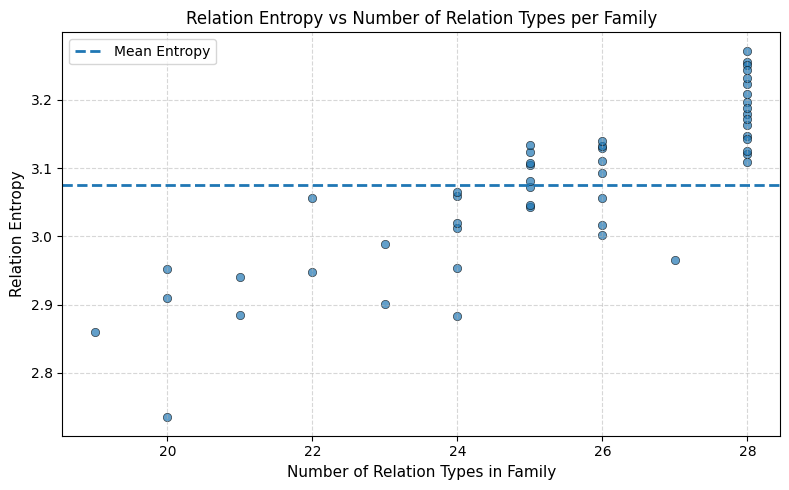

In [63]:
# import matplotlib.pyplot as plt

# plt.figure(figsize=(8, 5))

# plt.scatter(
#     entropy_vs_reltypes_df["num_relation_types"],
#     entropy_vs_reltypes_df["relation_entropy"],
#     alpha=0.7,
#     edgecolors="black",
#     linewidths=0.5
# )

# plt.xlabel("Number of Relation Types in Family", fontsize=11)
# plt.ylabel("Relation Entropy", fontsize=11)
# plt.title("Relation Entropy vs Number of Relation Types per Family", fontsize=12)

# plt.grid(True, linestyle="--", alpha=0.5)
# plt.tight_layout()
# plt.show()
mean_entropy = entropy_vs_reltypes_df["relation_entropy"].mean()

plt.figure(figsize=(8, 5))

plt.scatter(
    entropy_vs_reltypes_df["num_relation_types"],
    entropy_vs_reltypes_df["relation_entropy"],
    alpha=0.7,
    edgecolors="black",
    linewidths=0.5
)

plt.axhline(
    mean_entropy,
    linestyle="--",
    linewidth=2,
    label="Mean Entropy"
)

plt.xlabel("Number of Relation Types in Family", fontsize=11)
plt.ylabel("Relation Entropy", fontsize=11)
plt.title("Relation Entropy vs Number of Relation Types per Family", fontsize=12)

plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


In [64]:
# Detection of anomalous or conflicting marital relationships in the family knowledge graph
mother_relations = [r for r in relations if "mother" in r.lower()]
father_relations = [r for r in relations if "father" in r.lower()]

df_mothers = df[df["relation"].isin(mother_relations)].copy()
df_fathers = df[df["relation"].isin(father_relations)].copy()

# 1) child with >=2 fathers and at least one mother
mother_by_child = df_mothers.groupby("tail")["head"].apply(lambda s: sorted(set(s)))
father_by_child = df_fathers.groupby("tail")["head"].apply(lambda s: sorted(set(s)))
affair_child_multi_fathers = []
for child in sorted(set(mother_by_child.index) & set(father_by_child.index)):
    mothers = mother_by_child.loc[child]
    fathers = father_by_child.loc[child]
    if len(fathers) >= 2:
        affair_child_multi_fathers.append(
            {
                "child": child,
                "mothers": mothers,
                "fathers": fathers,
                "num_fathers": len(fathers),
            }
        )
affair_child_multi_fathers_df = pd.DataFrame(affair_child_multi_fathers)

# 2) child with >=2 mothers and at least one father
affair_child_multi_mothers = []
for child in sorted(set(mother_by_child.index) & set(father_by_child.index)):
    mothers = mother_by_child.loc[child]
    fathers = father_by_child.loc[child]
    if len(mothers) >= 2:
        affair_child_multi_mothers.append(
            {
                "child": child,
                "mothers": mothers,
                "fathers": fathers,
                "num_mothers": len(mothers),
            }
        )
affair_child_multi_mothers_df = pd.DataFrame(affair_child_multi_mothers)

# 3) father with >=2 mothers across children ("multiple wives" signal)
parents_by_child = df_mothers.merge(
    df_fathers, on="tail", suffixes=("_mother", "_father")
)[["tail", "head_mother", "head_father"]]
mothers_by_father = parents_by_child.groupby("head_father")["head_mother"].apply(
    lambda s: sorted(set(s))
)
affair_father_multi_wives = []
for father, mothers in mothers_by_father.items():
    if len(mothers) >= 2:
        affair_father_multi_wives.append(
            {
                "father": father,
                "mothers": mothers,
                "num_mothers": len(mothers),
            }
        )
affair_father_multi_wives_df = pd.DataFrame(affair_father_multi_wives)

# 4) mother with >=2 fathers across children ("multiple husbands" signal)
fathers_by_mother = parents_by_child.groupby("head_mother")["head_father"].apply(
    lambda s: sorted(set(s))
)
affair_mother_multi_husbands = []
for mother, fathers in fathers_by_mother.items():
    if len(fathers) >= 2:
        affair_mother_multi_husbands.append(
            {
                "mother": mother,
                "fathers": fathers,
                "num_fathers": len(fathers),
            }
        )
affair_mother_multi_husbands_df = pd.DataFrame(affair_mother_multi_husbands)

affair_child_multi_fathers_df, affair_child_multi_mothers_df, affair_father_multi_wives_df, affair_mother_multi_husbands_df

(           child                                         mothers  \
 0        adam125            [anastasia106, claudia109, marie113]   
 1       adam1281                    [larissa1275, valentina1272]   
 2        adam198      [emilia184, emma199, selina185, sophie187]   
 3        adam359               [hannah366, laura345, marlene344]   
 4        adam627            [clara615, lea618, lena606, nina611]   
 ..           ...                                             ...   
 589   vincent107                          [claudia109, marie113]   
 590  vincent1261                        [helga1238, natalie1249]   
 591   vincent704              [elena696, julia699, magdalena685]   
 592   vincent792               [laura790, sophie787, vanessa793]   
 593   vincent848  [anastasia847, anna842, olivia849, valerie843]   
 
                                             fathers  num_fathers  
 0                  [daniel114, emil110, vincent107]            3  
 1                        [christi

In [65]:
# fathers with >=2 wives where each wife has distinct (non-overlapping) children
parents_by_child = df_mothers.merge(
    df_fathers, on="tail", suffixes=("_mother", "_father")
)[["tail", "head_mother", "head_father"]]

# children per (father, mother) pair
children_by_parents = parents_by_child.groupby(
    ["head_father", "head_mother"]
)["tail"].apply(lambda s: sorted(set(s)))

records = []
for father, group in children_by_parents.groupby(level=0):
    mother_children = {
        mother: set(children_by_parents.loc[(father, mother)])
        for mother in group.index.get_level_values(1).unique()
    }
    mothers = sorted(mother_children.keys())
    if len(mothers) < 2:
        continue
    for i in range(len(mothers)):
        for j in range(i + 1, len(mothers)):
            m1, m2 = mothers[i], mothers[j]
            c1, c2 = mother_children[m1], mother_children[m2]
            if c1 and c2 and c1.isdisjoint(c2):
                records.append(
                    {
                        "father": father,
                        "mother_1": m1,
                        "mother_2": m2,
                        "children_1": sorted(c1),
                        "children_2": sorted(c2),
                        "num_children_1": len(c1),
                        "num_children_2": len(c2),
                    }
                )

father_two_wives_distinct_children_df = pd.DataFrame(records)
father_two_wives_distinct_children_df

,father,mother_1,mother_2,children_1,children_2,num_children_1,num_children_2
0,adam306,hannah291,larissa299,[laura308],"[adrian303, michael312]",1,2
1,adam306,hannah291,mia293,[laura308],"[maria295, marlene304, maximilian296]",1,3
2,adam306,larissa299,mia293,"[adrian303, michael312]","[maria295, marlene304, maximilian296]",2,3
3,adam426,karin440,magdalena430,"[emilia428, lena434]","[jan429, leonie422]",2,2
4,adam426,leonie422,magdalena430,[emilia428],"[jan429, leonie422]",1,2
...,...,...,...,...,...,...,...
1302,vincent973,elena998,helga976,[jonas999],"[angelina978, charlotte980, jakob984, luis989]",1,4
1303,vincent973,elena998,leonie975,[jonas999],"[felix986, nico997]",1,2
1304,vincent973,elena998,magdalena994,[jonas999],"[charlotte980, jakob984]",1,2
1305,vincent973,helga976,leonie975,"[angelina978, charlotte980, jakob984, luis989]","[felix986, nico997]",4,2


In [66]:
# Individual densities of families

family_density_records = []

for family_id, nodes in enumerate(components):
    # Subgraph for this family
    subgraph = G.subgraph(nodes)
    
    # Convert to undirected simple graph
    undirected_subgraph = nx.Graph(subgraph)
    
    # Compute density
    density = nx.density(undirected_subgraph)
    
    family_density_records.append(
        {
            "family_id": family_id,
            "family_size": undirected_subgraph.number_of_nodes(),
            "num_edges": undirected_subgraph.number_of_edges(),
            "density": density
        }
    )

In [67]:
family_density_df = pd.DataFrame(family_density_records)
family_density_df.head()


,family_id,family_size,num_edges,density
0,0,27,206,0.586895
1,1,26,107,0.329231
2,2,26,149,0.458462
3,3,26,151,0.464615
4,4,26,162,0.498462


In [68]:
# Summary stats for family densities
density_stats = {
    "mean": family_density_df["density"].mean(),
    "median": family_density_df["density"].median(),
    "max": family_density_df["density"].max(),
    "min": family_density_df["density"].min(),
}
pd.DataFrame([density_stats])

,mean,median,max,min
0,0.448985,0.447293,0.627692,0.28


In [69]:
# Family-level factors: number of relations and members
def _get_family_id(row):
    return node_to_family.get(row["head"], node_to_family.get(row["tail"]))
family_relations_df = df.copy()
family_relations_df["family_id"] = family_relations_df.apply(_get_family_id, axis=1)
family_relation_counts = (
    family_relations_df.groupby("family_id").size().rename("num_relations").reset_index()
    )
family_factors_df = family_density_df.merge(
    family_relation_counts, on="family_id", how="left"
    )
family_factors_df["num_members"] = family_factors_df["family_size"]
family_factors_df.head()

,family_id,family_size,num_edges,density,num_relations,num_members
0,0,27,206,0.586895,389,27
1,1,26,107,0.329231,207,26
2,2,26,149,0.458462,277,26
3,3,26,151,0.464615,287,26
4,4,26,162,0.498462,295,26


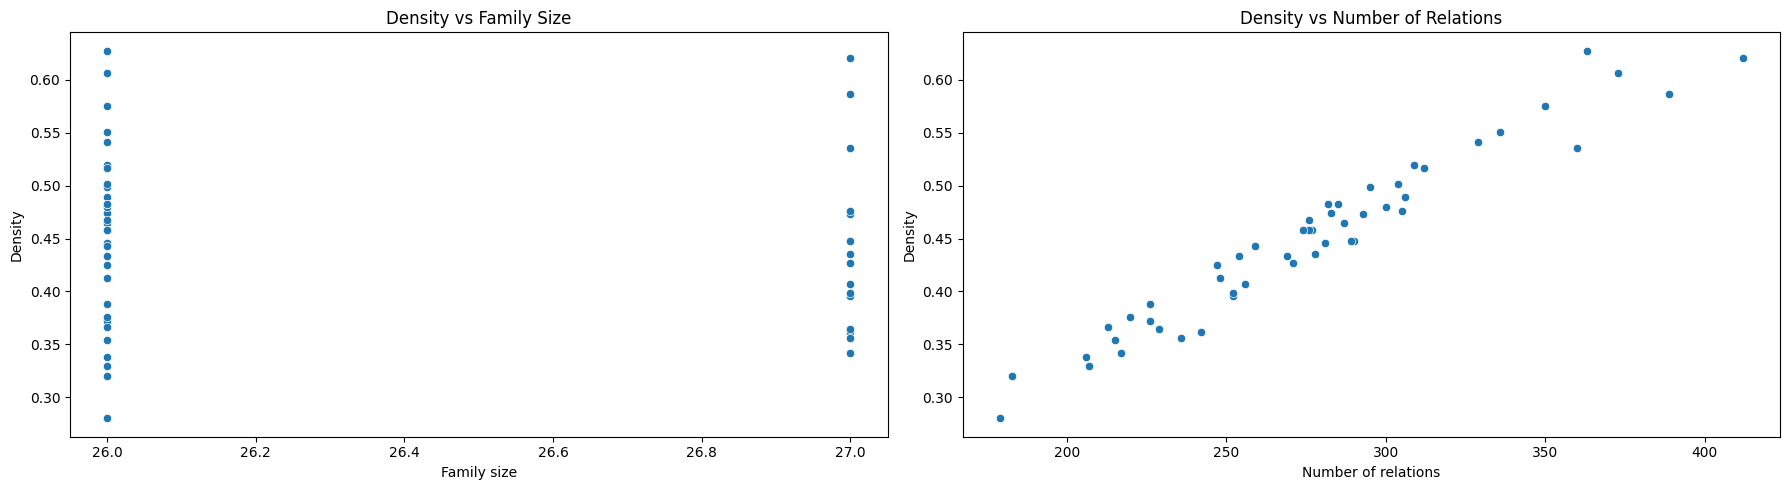

In [70]:
# Plot density vs factors
fig, axes = plt.subplots(1, 2, figsize=(18, 5))
sns.scatterplot(data=family_factors_df, x="family_size", y="density", ax=axes[0])
axes[0].set_title("Density vs Family Size")
axes[0].set_xlabel("Family size")
axes[0].set_ylabel("Density")

sns.scatterplot(data=family_factors_df, x="num_relations", y="density", ax=axes[1])
axes[1].set_title("Density vs Number of Relations")
axes[1].set_xlabel("Number of relations")
axes[1].set_ylabel("Density")

plt.tight_layout()

In [71]:
# Clustering coefficient for each node in the complete family graph
G_simple_undirected = nx.Graph(G)
clustering_coeff = nx.clustering(G_simple_undirected)
clustering_df = (
    pd.DataFrame(list(clustering_coeff.items()), columns=["node", "clustering_coeff"])
    .sort_values(by="clustering_coeff", ascending=False)
    .reset_index(drop=True)
 )
clustering_df.head()

,node,clustering_coeff
0,moritz8,1.0
1,emilia1308,1.0
2,emma7,1.0
3,marlene1278,1.0
4,paul1279,1.0


In [72]:
# Average clustering coefficient per family
clustering_family_df = (
    pd.DataFrame(
        [(node, coeff, node_to_family.get(node)) for node, coeff in clustering_coeff.items()],
        columns=["node", "clustering_coeff", "family_id"],
    )
    .dropna(subset=["family_id"])
    .groupby("family_id")["clustering_coeff"]
    .mean()
    .reset_index(name="avg_clustering_coeff")
    .sort_values(by="avg_clustering_coeff", ascending=False)
    .reset_index(drop=True)
 )
clustering_family_df.head()

,family_id,avg_clustering_coeff
0,33,0.896310
1,38,0.894643
2,48,0.877886
3,24,0.874696
4,29,0.853905


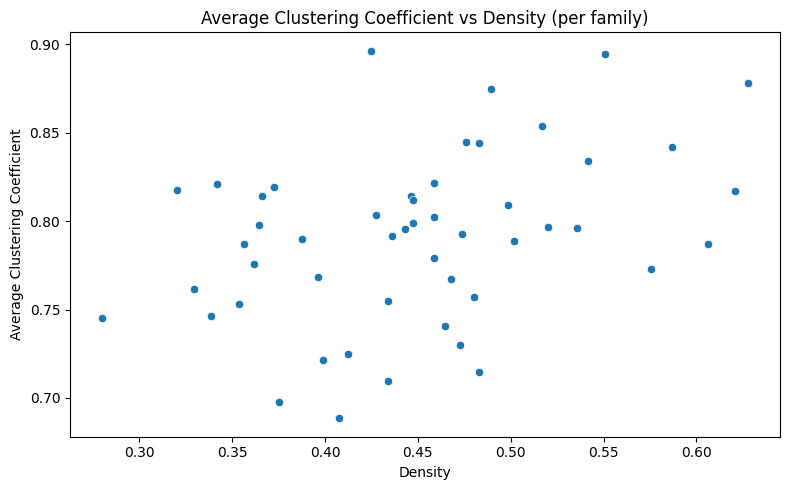

In [73]:
# Plot average clustering coefficient vs density per family
clustering_density_df = clustering_family_df.merge(
    family_density_df[["family_id", "density"]], on="family_id", how="left"
 )
plt.figure(figsize=(8, 5))
sns.scatterplot(data=clustering_density_df, x="density", y="avg_clustering_coeff")
plt.title("Average Clustering Coefficient vs Density (per family)")
plt.xlabel("Density")
plt.ylabel("Average Clustering Coefficient")
plt.tight_layout()

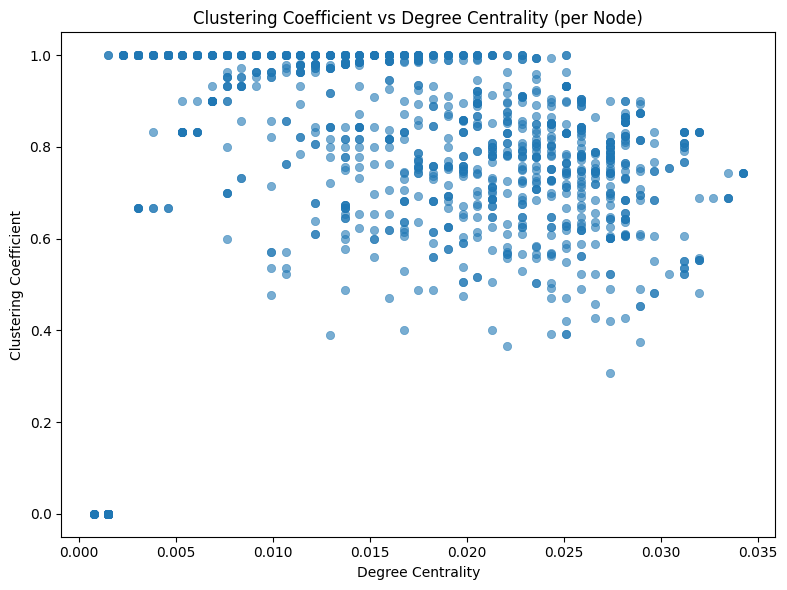

In [74]:
# Plot clustering coefficient vs degree centrality for each node
# Ensure degree centrality is available as a dataframe
deg_cent = nx.degree_centrality(G)
degree_centrality_df_local = pd.DataFrame(list(deg_cent.items()), columns=["node", "degree_centrality"])

# Merge with clustering coefficient dataframe
clustering_vs_degree_df = clustering_df.merge(
    degree_centrality_df_local, on="node", how="inner"
)

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=clustering_vs_degree_df,
    x="degree_centrality",
    y="clustering_coeff",
    alpha=0.6,
    edgecolor=None
)
plt.title("Clustering Coefficient vs Degree Centrality (per Node)")
plt.xlabel("Degree Centrality")
plt.ylabel("Clustering Coefficient")
plt.tight_layout()

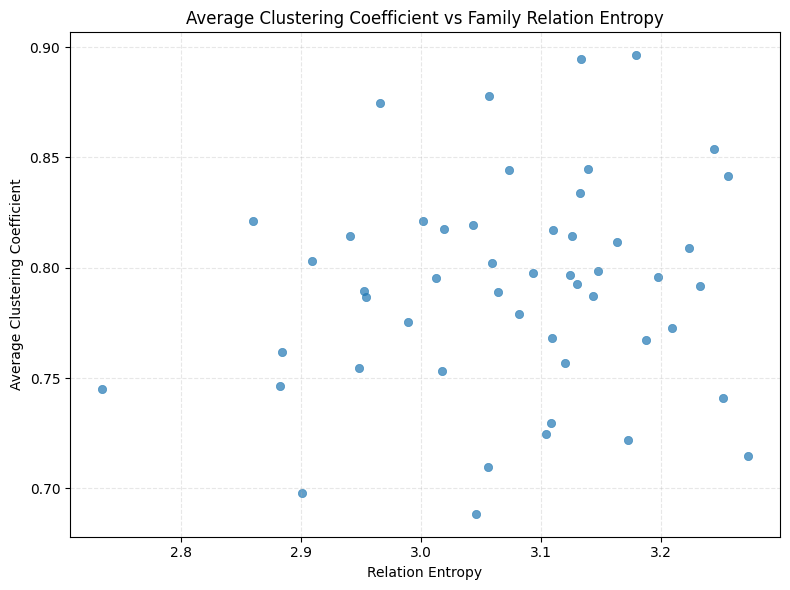

In [75]:
# Plot Clustering Coefficient vs Relation Entropy for each family
# Identify the correct entropy column (relation_entropy or entropy)
entropy_col = next((col for col in ["relation_entropy", "entropy"] if col in family_entropy_df.columns), None)

if entropy_col:
    # Merge clustering coefficient data with entropy data
    clustering_entropy_df = clustering_family_df.merge(
        family_entropy_df[["family_id", entropy_col]],
        on="family_id",
        how="inner"
    )

    plt.figure(figsize=(8, 6))
    sns.scatterplot(
        data=clustering_entropy_df,
        x=entropy_col,
        y="avg_clustering_coeff",
        alpha=0.7,
        edgecolor=None
    )
    plt.title("Average Clustering Coefficient vs Family Relation Entropy")
    plt.xlabel("Relation Entropy")
    plt.ylabel("Average Clustering Coefficient")
    plt.grid(True, linestyle="--", alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print(f"Entropy column not found. Available columns: {family_entropy_df.columns}")

In [76]:
# Family Diameter for all families
family_diameter_records = []

for family_id, nodes in enumerate(components):
    # Subgraph for this family
    subgraph = G.subgraph(nodes)
    
    # Convert to undirected simple graph for diameter calculation
    # (Diameter is typically defined for connected components)
    undirected_subgraph = nx.Graph(subgraph)
    
    if nx.is_connected(undirected_subgraph):
        diameter = nx.diameter(undirected_subgraph)
    else:
        # Should be connected as we derived components from weakly connected logic,
        # but just in case of any edge case if converting to simple graph disconnects it
        # (e.g. if directed connectivity matters differently). 
        # For undirected components from weakly_connected_components, it should be connected.
        diameter = max([nx.diameter(undirected_subgraph.subgraph(c)) for c in nx.connected_components(undirected_subgraph)])

    family_diameter_records.append(
        {
            "family_id": family_id,
            "diameter": diameter,
            "family_size": len(nodes)
        }
    )

family_diameter_df = pd.DataFrame(family_diameter_records)
family_diameter_df.head()

,family_id,diameter,family_size
0,0,3,27
1,1,3,26
2,2,4,26
3,3,5,26
4,4,4,26


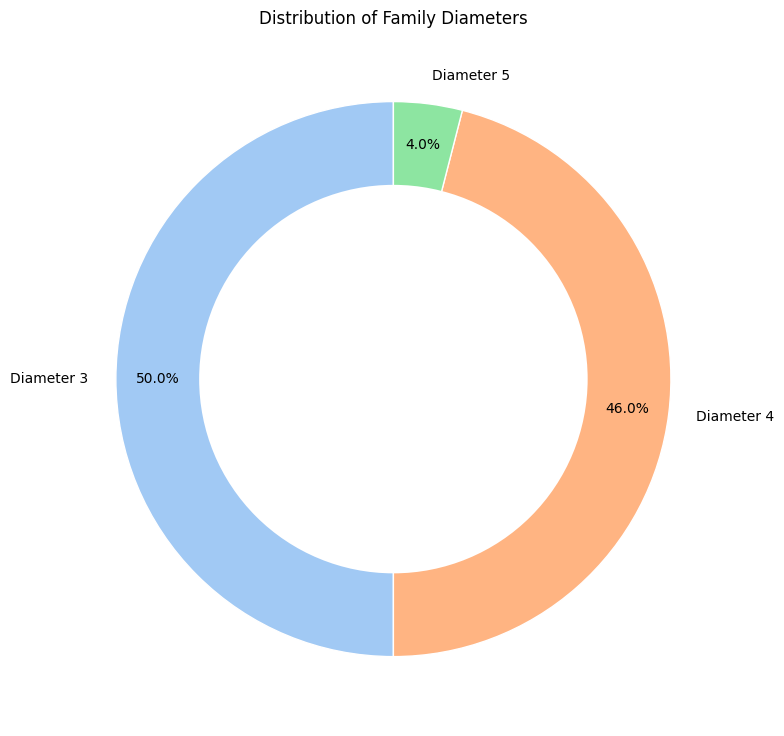

Family Diameter Counts:
diameter
3    25
4    23
5     2
Name: count, dtype: int64


In [77]:
# Distribution of Family Diameters
diameter_counts = family_diameter_df["diameter"].value_counts().sort_index()

plt.figure(figsize=(8, 8))
plt.pie(
    diameter_counts,
    labels=[f"Diameter {d}" for d in diameter_counts.index],
    autopct="%1.1f%%",
    startangle=90,
    pctdistance=0.85,
    colors=sns.color_palette("pastel"),
    wedgeprops={"edgecolor": "white", "linewidth": 1}
)

# Add a circle at the center to make it a donut chart (optional, but looks nice for distributions)
centre_circle = plt.Circle((0,0),0.70,fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title("Distribution of Family Diameters")
plt.tight_layout()
plt.show()

# Print the actual counts
print("Family Diameter Counts:")
print(diameter_counts)

In [78]:
# Leaf nodes (degree = 1) count per family
family_leaf_records = []

for family_id, nodes in enumerate(components):
    subgraph = G.subgraph(nodes)
    undirected_subgraph = nx.Graph(subgraph)

    leaf_count = sum(1 for _, deg in undirected_subgraph.degree() if deg == 1)

    family_leaf_records.append(
        {
            "family_id": family_id,
            "leaf_nodes": leaf_count,
            "family_size": undirected_subgraph.number_of_nodes()
        }
    )

family_leaf_df = pd.DataFrame(family_leaf_records)
family_leaf_df.head()

,family_id,leaf_nodes,family_size
0,0,2,27
1,1,1,26
2,2,1,26
3,3,3,26
4,4,1,26


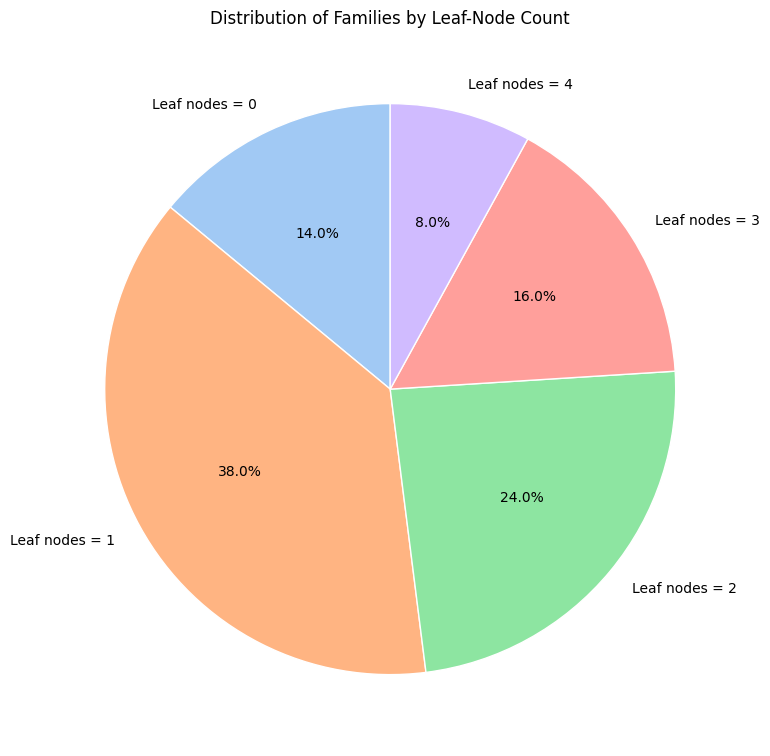

Families per leaf-node count:
leaf_nodes
0     7
1    19
2    12
3     8
4     4
Name: count, dtype: int64


In [79]:
# Pie chart: number of families by leaf-node count
leaf_count_distribution = family_leaf_df["leaf_nodes"].value_counts().sort_index()

plt.figure(figsize=(8, 8))
plt.pie(
    leaf_count_distribution.values,
    labels=[f"Leaf nodes = {cnt}" for cnt in leaf_count_distribution.index],
    autopct="%1.1f%%",
    startangle=90,
    colors=sns.color_palette("pastel"),
    wedgeprops={"edgecolor": "white", "linewidth": 1}
 )
plt.title("Distribution of Families by Leaf-Node Count")
plt.tight_layout()
plt.show()

print("Families per leaf-node count:")
print(leaf_count_distribution)

In [80]:
# Leaf node stats per family
leaf_node_stats = {
    "mean": family_leaf_df["leaf_nodes"].mean(),
    "median": family_leaf_df["leaf_nodes"].median(),
    "max": family_leaf_df["leaf_nodes"].max(),
    "min": family_leaf_df["leaf_nodes"].min(),
}
pd.DataFrame([leaf_node_stats])

,mean,median,max,min
0,1.66,1.0,4,0


In [81]:
# Number of generations per family
family_generation_records = []

for family_id, nodes in enumerate(components):
    subgraph = G.subgraph(nodes)
    directed_subgraph = nx.DiGraph(subgraph)
    
    if nx.is_directed_acyclic_graph(directed_subgraph):
        # Longest directed path length corresponds to max generations-1
        generations = nx.dag_longest_path_length(directed_subgraph) + 1
    else:
        # Fallback: use longest shortest path in undirected graph as a proxy
        undirected_subgraph = nx.Graph(subgraph)
        if nx.is_connected(undirected_subgraph):
            generations = nx.diameter(undirected_subgraph) + 1
        else:
            # Take max diameter across components if any disconnected parts exist
            generations = max(
            
                nx.diameter(undirected_subgraph.subgraph(c)) + 1
                for c in nx.connected_components(undirected_subgraph)
            )

    family_generation_records.append(
        {
            "family_id": family_id,
            "generations": generations,
            "family_size": len(nodes)
        }
    )

family_generation_df = pd.DataFrame(family_generation_records)
family_generation_df.head()

,family_id,generations,family_size
0,0,4,27
1,1,4,26
2,2,5,26
3,3,6,26
4,4,5,26


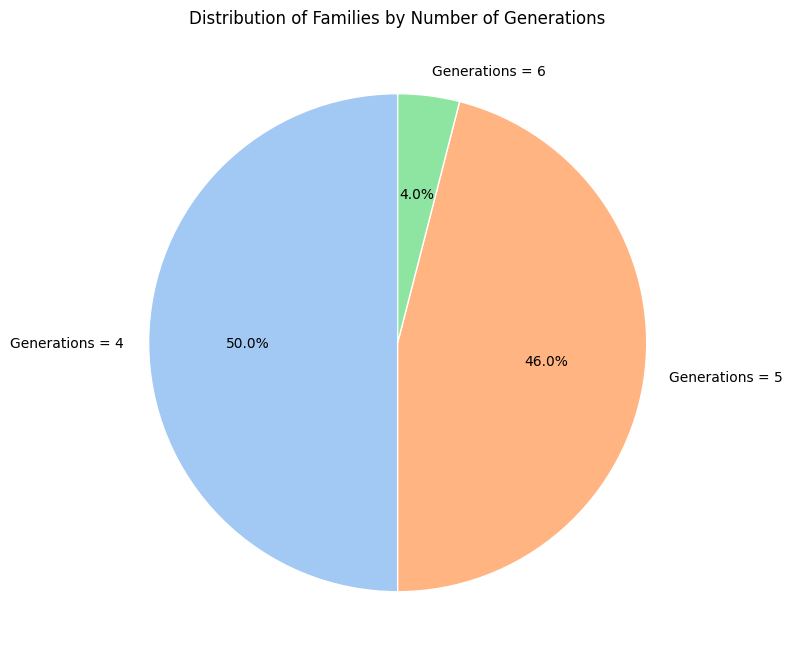

Families per generation count:
generations
4    25
5    23
6     2
Name: count, dtype: int64


In [82]:
# Pie chart: number of families by generations
generation_counts = family_generation_df["generations"].value_counts().sort_index()

plt.figure(figsize=(8, 8))
plt.pie(
    generation_counts.values,
    labels=[f"Generations = {g}" for g in generation_counts.index],
    autopct="%1.1f%%",
    startangle=90,
    colors=sns.color_palette("pastel"),
    wedgeprops={"edgecolor": "white", "linewidth": 1}
)
plt.title("Distribution of Families by Number of Generations")
plt.tight_layout()
plt.show()

print("Families per generation count:")
print(generation_counts)

In [83]:
# Generation count stats per family
generation_stats = {
    "mean": family_generation_df["generations"].mean(),
    "median": family_generation_df["generations"].median(),
    "max": family_generation_df["generations"].max(),
    "min": family_generation_df["generations"].min(),
}
pd.DataFrame([generation_stats])

,mean,median,max,min
0,4.54,4.5,6,4


In [84]:
# Number of couples per family
mother_relations = [r for r in relations if "mother" in r.lower()]
father_relations = [r for r in relations if "father" in r.lower()]

df_mothers = df[df["relation"].isin(mother_relations)].copy()
df_fathers = df[df["relation"].isin(father_relations)].copy()

# Map child -> mother(s) and child -> father(s)
mother_by_child = df_mothers.groupby("tail")["head"].apply(lambda s: sorted(set(s)))
father_by_child = df_fathers.groupby("tail")["head"].apply(lambda s: sorted(set(s)))

family_couple_records = []
for family_id, nodes in enumerate(components):
    # children in this family
    family_children = [n for n in nodes if n in mother_by_child.index and n in father_by_child.index]
    couples = set()
    for child in family_children:
        for m in mother_by_child.loc[child]:
            for f in father_by_child.loc[child]:
                couples.add(tuple(sorted([m, f])))
    family_couple_records.append(
        {
            "family_id": family_id,
            "num_couples": len(couples),
            "family_size": len(nodes)
        }
    )

family_couples_df = pd.DataFrame(family_couple_records)
family_couples_df.head()

,family_id,num_couples,family_size
0,0,32,27
1,1,60,26
2,2,55,26
3,3,39,26
4,4,34,26


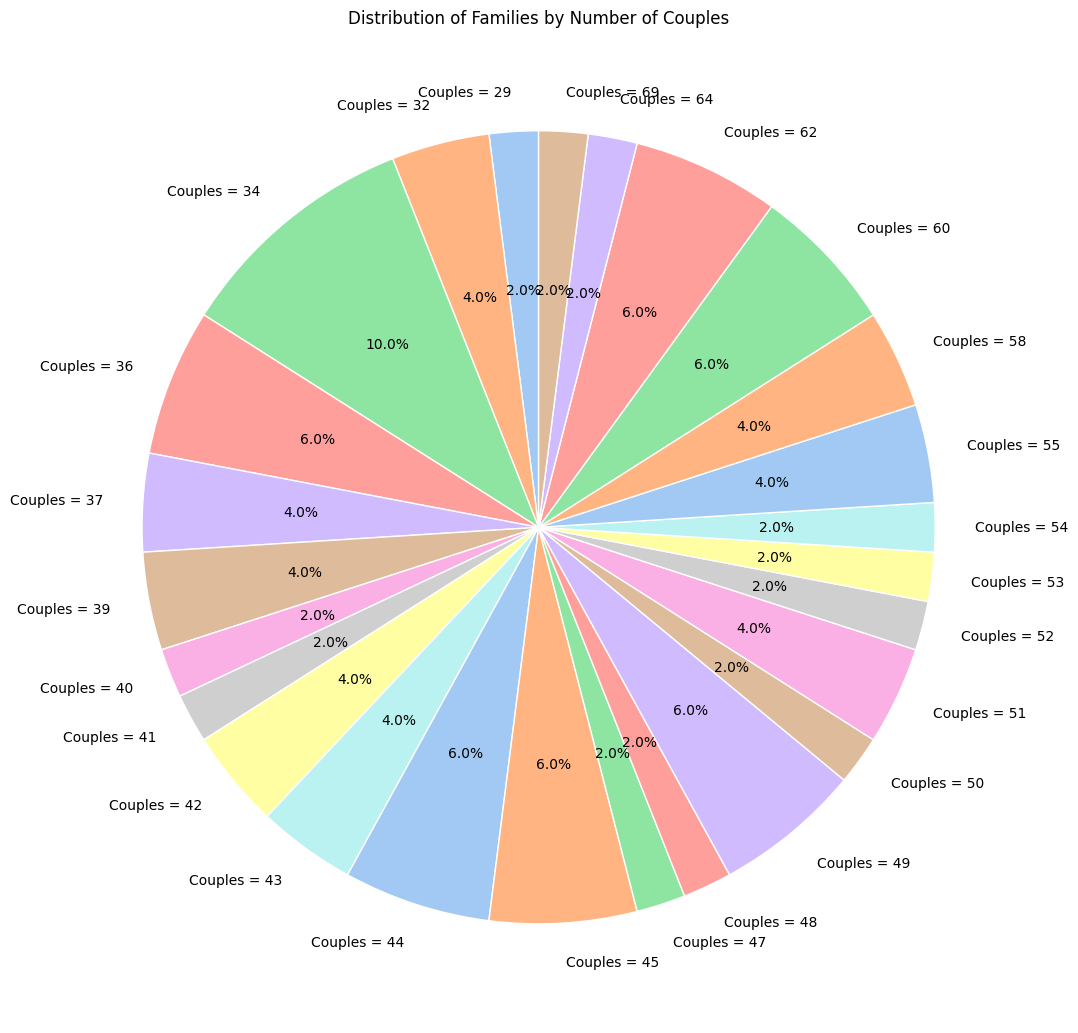

Families per couple count:
num_couples
29    1
32    2
34    5
36    3
37    2
39    2
40    1
41    1
42    2
43    2
44    3
45    3
47    1
48    1
49    3
50    1
51    2
52    1
53    1
54    1
55    2
58    2
60    3
62    3
64    1
69    1
Name: count, dtype: int64


In [85]:
# Pie chart: number of families by couple count
couple_count_distribution = family_couples_df["num_couples"].value_counts().sort_index()

plt.figure(figsize=(11, 11))
plt.pie(
    couple_count_distribution.values,
    labels=[f"Couples = {c}" for c in couple_count_distribution.index],
    autopct="%1.1f%%",
    startangle=90,
    colors=sns.color_palette("pastel"),
    wedgeprops={"edgecolor": "white", "linewidth": 1}
)
plt.title("Distribution of Families by Number of Couples")
plt.tight_layout()
plt.show()

print("Families per couple count:")
print(couple_count_distribution)

In [86]:
# Couple count stats per family
couple_stats = {
    "mean": family_couples_df["num_couples"].mean(),
    "median": family_couples_df["num_couples"].median(),
    "max": family_couples_df["num_couples"].max(),
    "min": family_couples_df["num_couples"].min(),
}
pd.DataFrame([couple_stats])

,mean,median,max,min
0,46.38,45.0,69,29


In [87]:
# Children per couple in each family
family_couple_children_records = []

for family_id, nodes in enumerate(components):
    subgraph = G.subgraph(nodes)
    undirected_subgraph = nx.Graph(subgraph)
    
    # children in this family
    family_children = [n for n in nodes if n in mother_by_child.index and n in father_by_child.index]
    couples = {}
    for child in family_children:
        for m in mother_by_child.loc[child]:
            for f in father_by_child.loc[child]:
                couple = tuple(sorted([m, f]))
                if couple not in couples:
                    couples[couple] = set()
                couples[couple].add(child)

    for (m, f), children in couples.items():
        family_couple_children_records.append(
            {
                "family_id": family_id,
                "mother": m,
                "father": f,
                "num_children": len(children),
                "children": sorted(children)
            }
        )

family_couple_children_df = pd.DataFrame(family_couple_children_records)
family_couple_children_df.head()

,family_id,mother,father,num_children,children
0,0,david20,ella19,9,"[adam9, dominik2, elias6, isabella11, lisa5, n..."
1,0,dominik2,ella19,7,"[adam9, elias6, isabella11, lisa5, nico4, oska..."
2,0,ella19,moritz8,8,"[adam9, elias6, isabella11, lisa5, nico4, oliv..."
3,0,ella19,oliver3,2,"[elias6, lisa5]"
4,0,david20,emma7,8,"[adam9, elias6, isabella11, lisa5, nico4, oliv..."


In [88]:
# Average number of children per couple for each family
avg_children_per_couple_df = (
    family_couple_children_df.groupby("family_id")["num_children"]
    .mean()
    .reset_index(name="avg_children_per_couple")
    .sort_values(by="avg_children_per_couple", ascending=False)
    .reset_index(drop=True)
 )
avg_children_per_couple_df.head()

,family_id,avg_children_per_couple
0,39,5.750000
1,48,5.270270
2,42,5.229167
3,31,4.200000
4,11,4.125000


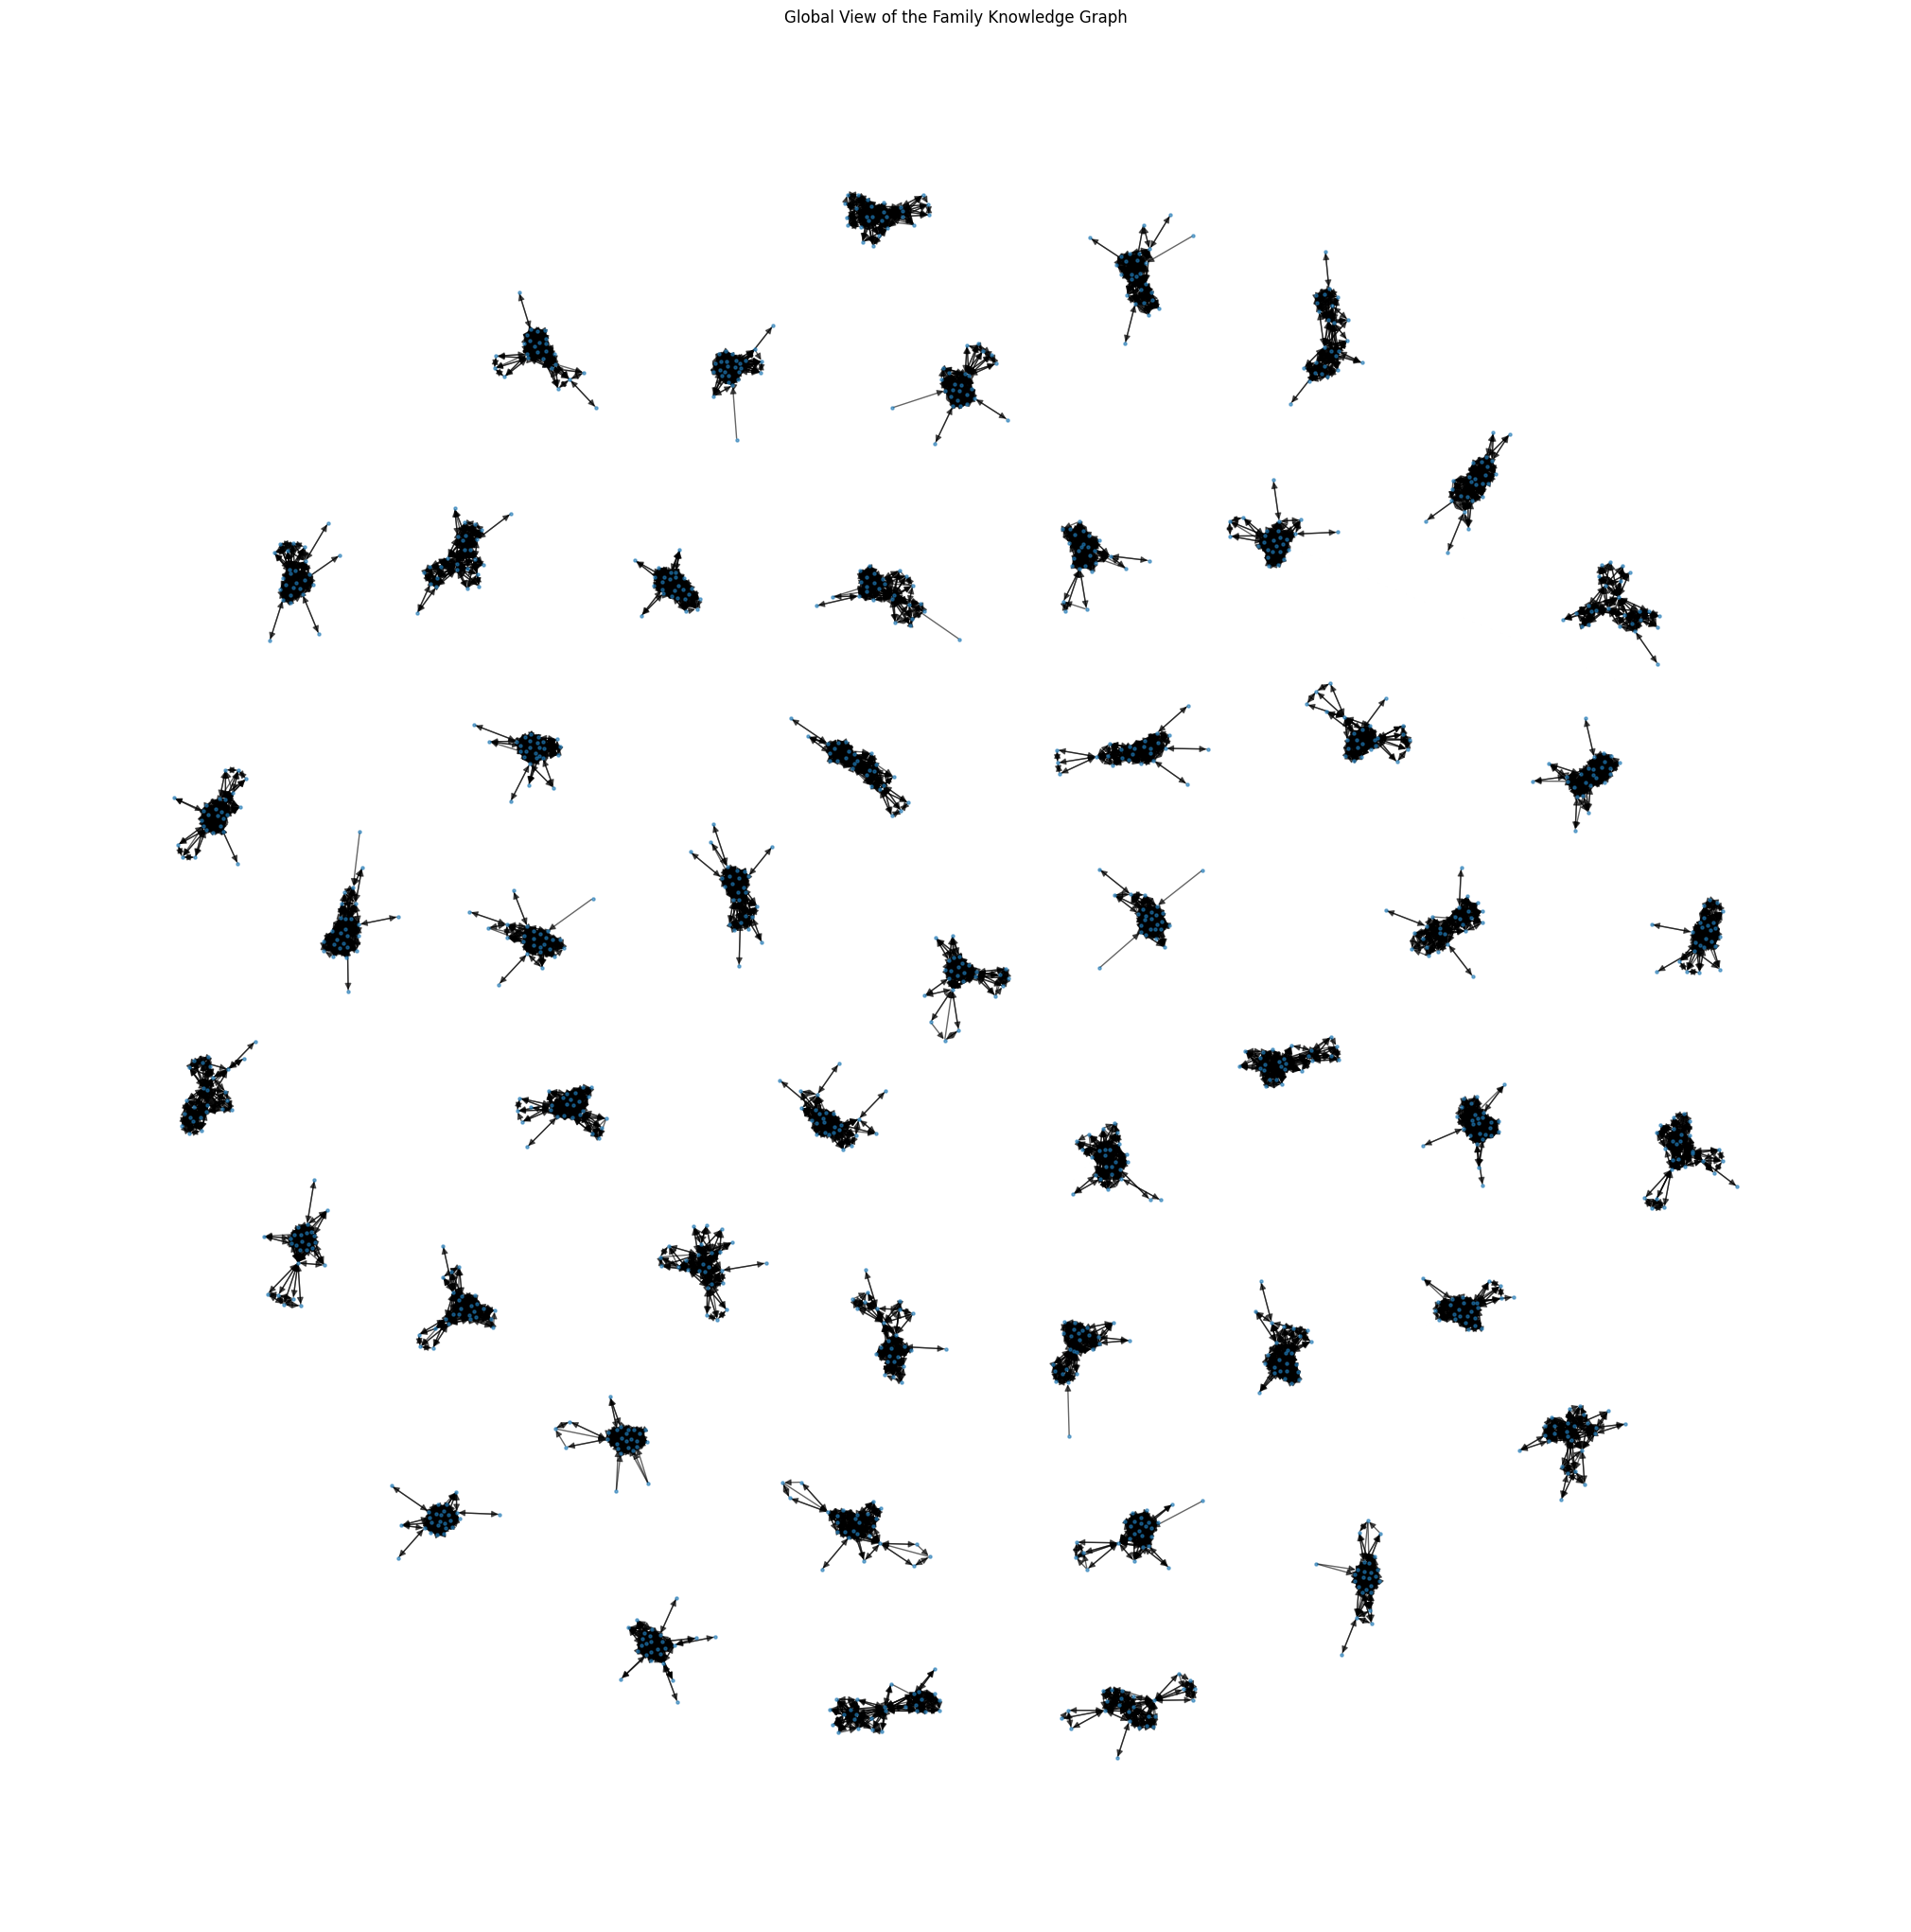

In [92]:
import matplotlib.pyplot as plt
import networkx as nx

plt.figure(figsize=(20, 20))

pos = nx.spring_layout(G, seed=42)

nx.draw(
    G,
    pos,
    node_size=5,
    alpha=0.6,
    with_labels=False
)

plt.title("Global View of the Family Knowledge Graph")
plt.show()
